# Adult Census Income – Full ML Pipeline
Predicts whether a person earns **>50K** or **≤50K** per year using the UCI Adult Census Income dataset.

| Column | Description | Type |
|---|---|---|
| age | Age of the person | Numeric |
| workclass | Employer type (Private, Gov, …) | Categorical |
| fnlwgt | Census statistical weight | Numeric |
| education | Education level | Categorical |
| education.num | Numeric encoding of education | Numeric |
| marital.status | Marital status | Categorical |
| occupation | Job type | Categorical |
| relationship | Family role | Categorical |
| race | Race | Categorical |
| sex | Sex | Binary |
| capital.gain | Capital gains | Numeric |
| capital.loss | Capital losses | Numeric |
| hours.per.week | Weekly working hours | Numeric |
| native.country | Country of origin | Categorical |
| income | Target: income level | Binary |


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Load Data
> Update the path below to point to your CSV file.

In [2]:
# Update this path if running locally
# df = pd.read_csv('Adult_Census_Income.csv', na_values=['?'])
# For Google Colab:
# df = pd.read_csv('/content/Adult Census Income.csv', na_values=['?'])

df = pd.read_csv('Adult Census Income.csv', na_values=['?'])
print('Shape:', df.shape)
df.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 3. Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
print('Missing values:')
df.isnull().sum().sort_values(ascending=False)

Missing values:


occupation        1843
workclass         1836
native.country     583
fnlwgt               0
education            0
education.num        0
age                  0
marital.status       0
relationship         0
sex                  0
race                 0
capital.gain         0
capital.loss         0
hours.per.week       0
income               0
dtype: int64

In [6]:
print('Duplicates:', df.duplicated().sum())

Duplicates: 24


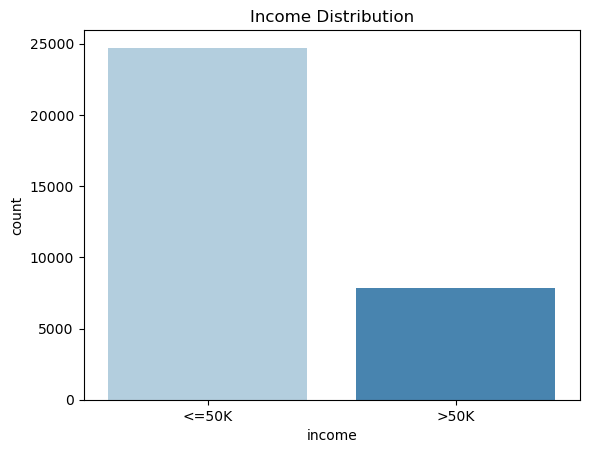

In [7]:
# Target distribution
sns.countplot(x='income', data=df, palette='Blues')
plt.title('Income Distribution')
plt.show()

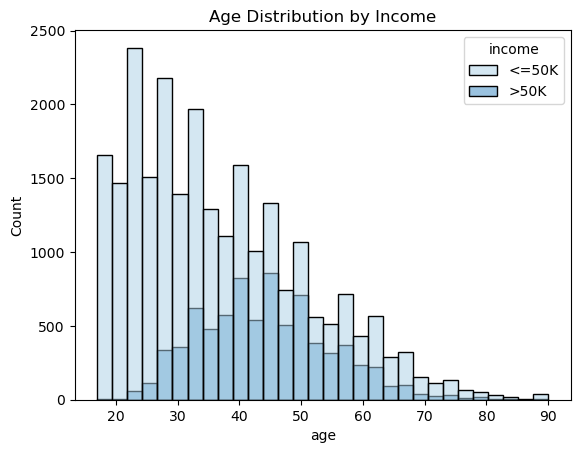

In [8]:
# Age distribution by income
sns.histplot(data=df, x='age', hue='income', bins=30, palette='Blues')
plt.title('Age Distribution by Income')
plt.show()

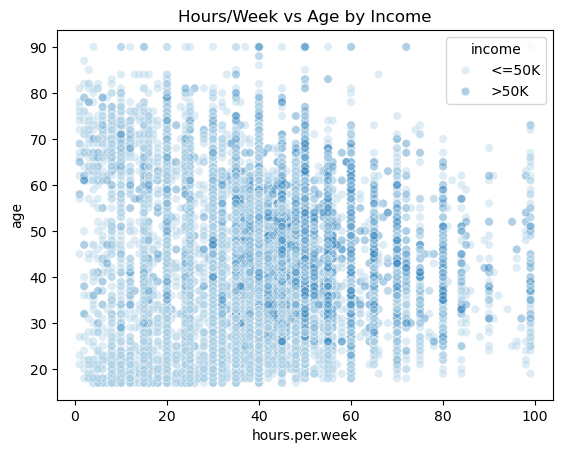

In [9]:
# Hours per week vs age, coloured by income
sns.scatterplot(data=df, x='hours.per.week', y='age', hue='income', alpha=0.4, palette='Blues')
plt.title('Hours/Week vs Age by Income')
plt.show()

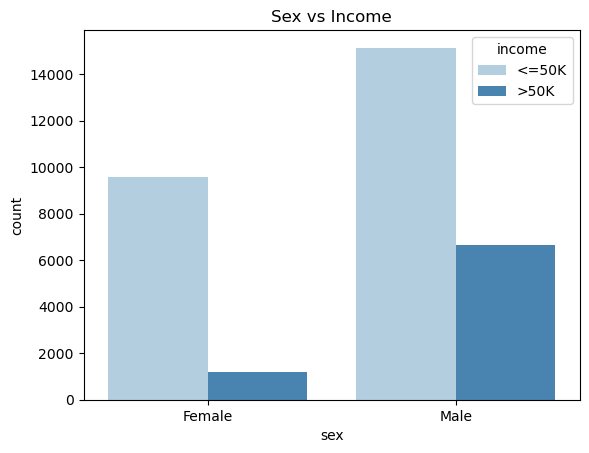

In [10]:
# Sex count by income
sns.countplot(data=df, x='sex', hue='income', palette='Blues')
plt.title('Sex vs Income')
plt.show()

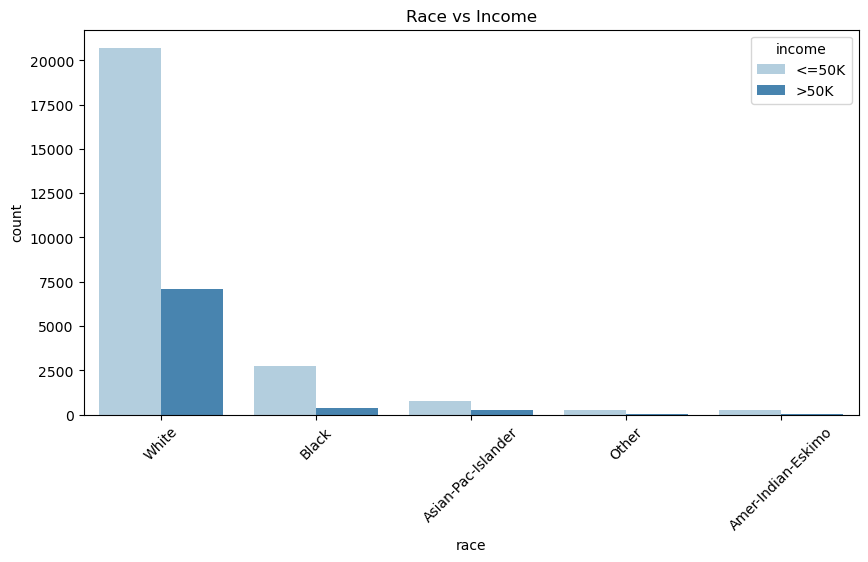

In [11]:
# Race count by income
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='race', hue='income', palette='Blues')
plt.xticks(rotation=45)
plt.title('Race vs Income')
plt.show()

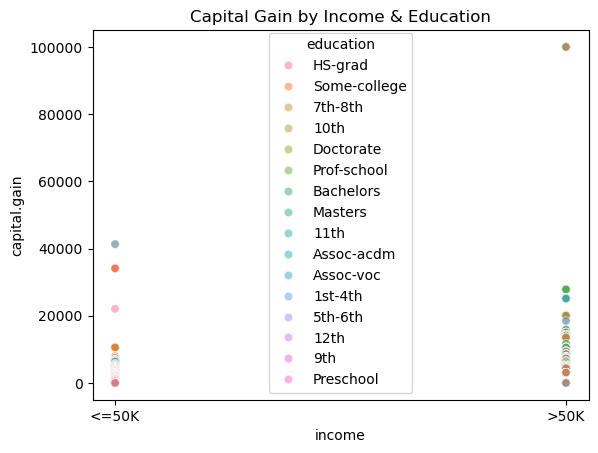

In [12]:
# Capital gain scatter
sns.scatterplot(data=df, y='capital.gain', x='income', hue='education', alpha=0.5)
plt.title('Capital Gain by Income & Education')
plt.show()

## 4. Preprocessing

In [13]:
# Remove duplicates
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print('Shape after dedup:', df.shape)

Shape after dedup: (32537, 15)


In [14]:
# Split features and target
X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=15, stratify=y)

for frame in [X_train, X_test, y_train, y_test]:
    frame.reset_index(drop=True, inplace=True)

print('Train size:', X_train.shape, '| Test size:', X_test.shape)

Train size: (26029, 14) | Test size: (6508, 14)


In [15]:
# Impute missing values in categorical columns
impute_cols = ['occupation', 'workclass', 'native.country']
imputer = SimpleImputer(strategy='most_frequent')
X_train[impute_cols] = imputer.fit_transform(X_train[impute_cols])
X_test[impute_cols]  = imputer.transform(X_test[impute_cols])

print('Remaining NaNs – train:', X_train.isnull().sum().sum(),
      '| test:', X_test.isnull().sum().sum())

Remaining NaNs – train: 0 | test: 0


In [16]:
# Drop high-cardinality columns (education already encoded numerically; native.country too sparse)
drop_cols = ['education', 'native.country']
X_train.drop(drop_cols, axis=1, inplace=True)
X_test.drop(drop_cols,  axis=1, inplace=True)
print('Remaining columns:', X_train.columns.tolist())

Remaining columns: ['age', 'workclass', 'fnlwgt', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week']


In [18]:
# Encode categorical columns – one LabelEncoder per column (FIX vs original notebook)
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns to encode:', cat_cols)

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    # Safe transform: unseen labels mapped to -1 instead of raising ValueError
    X_test[col] = X_test[col].map(
        lambda x, _le=le: int(_le.transform([x])[0]) if x in _le.classes_ else -1
    )
    label_encoders[col] = le

Categorical columns to encode: ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex']


In [19]:
# Encode target
le_y = LabelEncoder()
y_train_enc = le_y.fit_transform(y_train)
y_test_enc  = le_y.transform(y_test)
print('Classes:', le_y.classes_)

Classes: ['<=50K' '>50K']


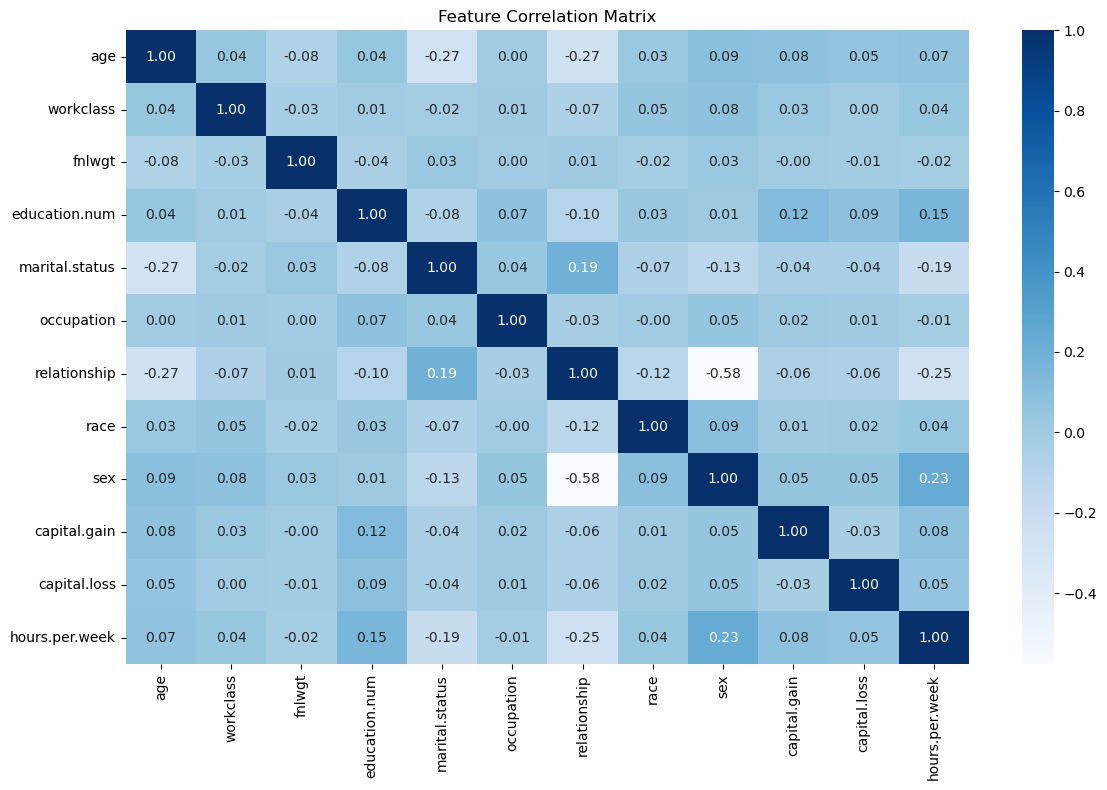

In [20]:
# Correlation heatmap (after encoding)
corr = np.corrcoef(X_train, rowvar=False)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=X_train.columns, yticklabels=X_train.columns)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [21]:
# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

## 5. Model Training & Evaluation

### 5.1 Logistic Regression

Logistic Regression Accuracy: 0.8216041794714198
              precision    recall  f1-score   support

       <=50K       0.84      0.94      0.89      4940
        >50K       0.71      0.44      0.54      1568

    accuracy                           0.82      6508
   macro avg       0.78      0.69      0.72      6508
weighted avg       0.81      0.82      0.81      6508



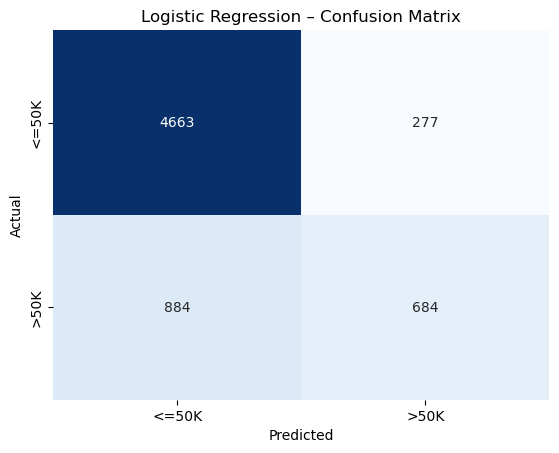

In [22]:
log_reg = LogisticRegression(random_state=15, solver='liblinear', max_iter=1000)
log_reg.fit(X_train_s, y_train_enc)
y_pred_lr = log_reg.predict(X_test_s)

print('Logistic Regression Accuracy:', accuracy_score(y_test_enc, y_pred_lr))
print(classification_report(y_test_enc, y_pred_lr, target_names=le_y.classes_))

sns.heatmap(confusion_matrix(y_test_enc, y_pred_lr), annot=True, fmt='d',
            cmap='Blues', cbar=False, xticklabels=le_y.classes_, yticklabels=le_y.classes_)
plt.title('Logistic Regression – Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

### 5.2 Decision Tree

Decision Tree Accuracy: 0.8103872157344807
              precision    recall  f1-score   support

       <=50K       0.88      0.87      0.88      4940
        >50K       0.61      0.61      0.61      1568

    accuracy                           0.81      6508
   macro avg       0.74      0.74      0.74      6508
weighted avg       0.81      0.81      0.81      6508



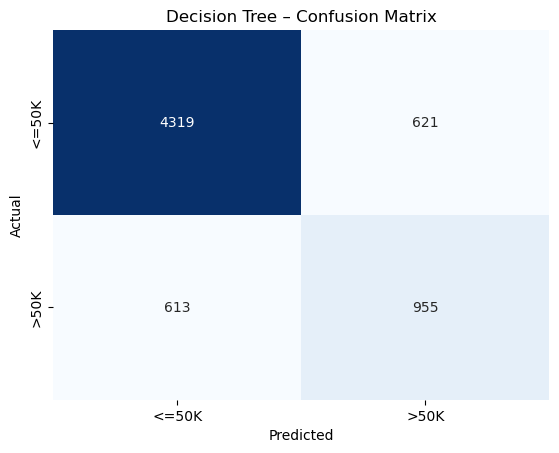

In [23]:
dt = DecisionTreeClassifier(random_state=15)
dt.fit(X_train_s, y_train_enc)
y_pred_dt = dt.predict(X_test_s)

print('Decision Tree Accuracy:', accuracy_score(y_test_enc, y_pred_dt))
print(classification_report(y_test_enc, y_pred_dt, target_names=le_y.classes_))

sns.heatmap(confusion_matrix(y_test_enc, y_pred_dt), annot=True, fmt='d',
            cmap='Blues', cbar=False, xticklabels=le_y.classes_, yticklabels=le_y.classes_)
plt.title('Decision Tree – Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

### 5.3 Random Forest

Random Forest Accuracy: 0.8587891825445605
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4940
        >50K       0.75      0.62      0.68      1568

    accuracy                           0.86      6508
   macro avg       0.82      0.78      0.79      6508
weighted avg       0.85      0.86      0.85      6508



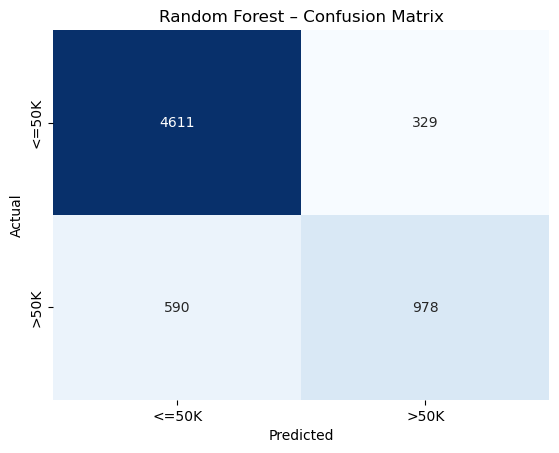

In [24]:
rf = RandomForestClassifier(random_state=15, n_estimators=100)
rf.fit(X_train_s, y_train_enc)
y_pred_rf = rf.predict(X_test_s)

print('Random Forest Accuracy:', accuracy_score(y_test_enc, y_pred_rf))
print(classification_report(y_test_enc, y_pred_rf, target_names=le_y.classes_))

sns.heatmap(confusion_matrix(y_test_enc, y_pred_rf), annot=True, fmt='d',
            cmap='Blues', cbar=False, xticklabels=le_y.classes_, yticklabels=le_y.classes_)
plt.title('Random Forest – Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

### 5.4 K-Nearest Neighbors

KNN Accuracy: 0.8294406883835279
              precision    recall  f1-score   support

       <=50K       0.87      0.91      0.89      4940
        >50K       0.67      0.59      0.62      1568

    accuracy                           0.83      6508
   macro avg       0.77      0.75      0.76      6508
weighted avg       0.82      0.83      0.83      6508



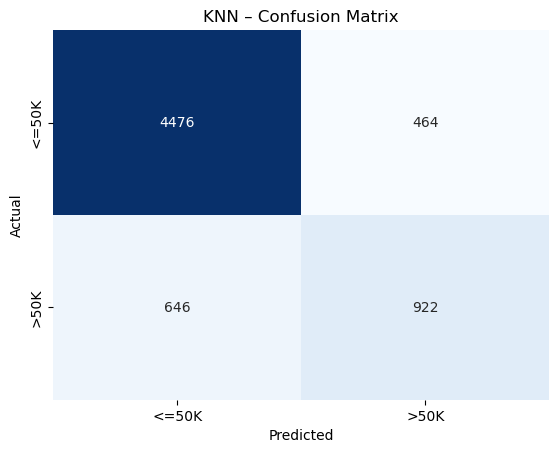

In [25]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train_enc)
y_pred_knn = knn.predict(X_test_s)

print('KNN Accuracy:', accuracy_score(y_test_enc, y_pred_knn))
print(classification_report(y_test_enc, y_pred_knn, target_names=le_y.classes_))

sns.heatmap(confusion_matrix(y_test_enc, y_pred_knn), annot=True, fmt='d',
            cmap='Blues', cbar=False, xticklabels=le_y.classes_, yticklabels=le_y.classes_)
plt.title('KNN – Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

## 6. Model Comparison

              Model  Accuracy
      Random Forest  0.858789
                KNN  0.829441
Logistic Regression  0.821604
      Decision Tree  0.810387


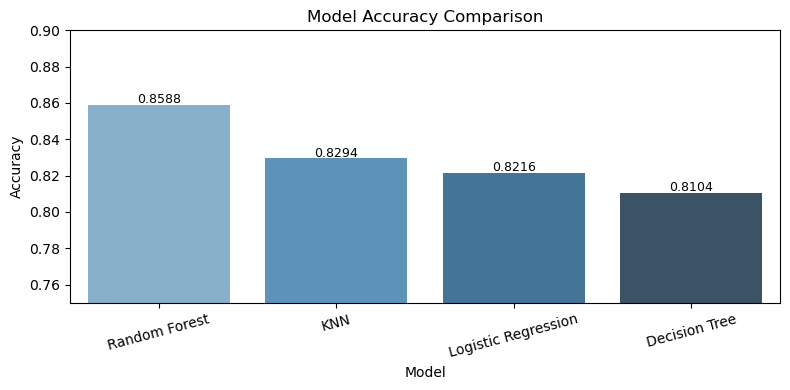

In [26]:
results = {
    'Logistic Regression': accuracy_score(y_test_enc, y_pred_lr),
    'Decision Tree':       accuracy_score(y_test_enc, y_pred_dt),
    'Random Forest':       accuracy_score(y_test_enc, y_pred_rf),
    'KNN':                 accuracy_score(y_test_enc, y_pred_knn),
}

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df.sort_values('Accuracy', ascending=False, inplace=True)
print(results_df.to_string(index=False))

plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x='Model', y='Accuracy', palette='Blues_d')
plt.ylim(0.75, 0.90)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
for i, row in results_df.reset_index().iterrows():
    plt.text(i, row['Accuracy'] + 0.001, f"{row['Accuracy']:.4f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Save Best Model (for Deployment)

In [27]:
import joblib

joblib.dump(rf,                       'model.pkl')
joblib.dump(scaler,                   'scaler.pkl')
joblib.dump(imputer,                  'imputer.pkl')
joblib.dump(label_encoders,           'label_encoders.pkl')
joblib.dump(le_y,                     'label_encoder_y.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_cols.pkl')

print('Saved:', ['model.pkl', 'scaler.pkl', 'imputer.pkl',
                 'label_encoders.pkl', 'label_encoder_y.pkl', 'feature_cols.pkl'])

Saved: ['model.pkl', 'scaler.pkl', 'imputer.pkl', 'label_encoders.pkl', 'label_encoder_y.pkl', 'feature_cols.pkl']
